# XÁC ĐỊNH TẬP PHỔ BIẾN VỚI GIẢI THUẬT APRIORI

## 1. Mục tiêu

Mục tiêu của bài thực hành là áp dụng giải thuật Apriori để xác định tập mục phổ biến và sinh luật kết hợp (association rules) từ dữ liệu mua hàng tại siêu thị.

Thông qua các luật kết hợp, ta có thể phát hiện những nhóm sản phẩm thường được mua cùng nhau, hỗ trợ doanh nghiệp trong việc trưng bày sản phẩm, tạo combo, gợi ý mua hàng và các chiến lược marketing khác.

## 2. Cài đặt thư viện và nạp dữ liệu

In [1]:
!pip install apyori

import pandas as pd
from apyori import apriori

  Preparing metadata (setup.py) ... done
  Created wheel for apyori: filename=apyori-1.1.2-py3-none-any.whl size=5954 sha256=7f554df7fc75442272e4248747c81557d1b6ef4cbd9c9b591efdc78ff7b91b2e
  Stored in directory: /root/.cache/pip/wheels/7f/49/e3/42c73b19a264de37129fadaa0c52f26cf50e87de08fb9804af
Successfully built apyori


In [2]:
# Đọc dữ liệu Online Retail
online = pd.read_excel("Online Retail.xlsx", sheet_name="Online Retail")

print("5 dòng đầu tiên:")
print(online.head())

print("Thông tin dữ liệu:")
print(online.info())

5 dòng đầu tiên:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype   

**Nhận xét dữ liệu ban đầu:**

Dữ liệu gồm hơn 540.000 giao dịch với 8 thuộc tính mô tả chi tiết hoạt động mua bán tại cửa hàng trực tuyến trong năm 2010–2011. Một số cột có giá trị thiếu, đặc biệt là Description và CustomerID. Tuy nhiên, bài toán Apriori chỉ yêu cầu thông tin sản phẩm và hóa đơn nên các giá trị thiếu ở CustomerID không ảnh hưởng. Dữ liệu vẫn cần được làm sạch vì có các hóa đơn hủy (InvoiceNo chứa ký tự ‘C’) và các giao dịch có Quantity ≤ 0. Việc xử lý các vấn đề này giúp đảm bảo độ chính xác khi trích xuất tập phổ biến và luật kết hợp.

## 3. Tiền xử lý dữ liệu

Bộ dữ liệu chứa nhiều hóa đơn bị hủy (InvoiceNo bắt đầu bằng 'C'), các giao dịch Quantity ≤ 0, hoặc các dòng có Description bị thiếu. Ta cần làm sạch ttrước khi đưa vào thuật toán Apriori.

In [3]:
# Xác định hóa đơn bị hủy
online["IsCPresent"] = online["InvoiceNo"].astype(str).apply(lambda x: 1 if 'C' in x else 0)

# Lọc dữ liệu hợp lệ
online1 = (
    online
    .loc[online["Quantity"] > 0]
    .loc[online["IsCPresent"] != 1]
    .loc[:, ["InvoiceNo", "Description"]]
    .dropna()
)

print("Số dòng sau làm sạch:", len(online1))
online1.head()


Số dòng sau làm sạch: 530693


,InvoiceNo,Description
0,536365,WHITE HANGING HEART T-LIGHT HOLDER
1,536365,WHITE METAL LANTERN
2,536365,CREAM CUPID HEARTS COAT HANGER
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE
4,536365,RED WOOLLY HOTTIE WHITE HEART.


**Nhận xét dữ liệu sau khi làm sạch:**

Sau khi loại bỏ hóa đơn hủy, các dòng thiếu mô tả sản phẩm và các giao dịch không hợp lệ (Quantity ≤ 0), tập dữ liệu còn hơn 530.000 dòng. Mỗi dòng bao gồm InvoiceNo và Description, phù hợp cho việc gom nhóm theo hóa đơn. Các mô tả sản phẩm sau xử lý đều đầy đủ, thống nhất, đảm bảo chất lượng cho việc xây dựng danh sách giao dịch đưa vào thuật toán Apriori.

## 4. Tạo danh sách giao dịch

Giải thuật Apriori (trong thư viện apyori) yêu cầu dữ liệu ở dạng list các list, mỗi list là các sản phẩm trong một hóa đơn.

In [4]:
# Lấy danh sách 5000 hóa đơn để chạy thuật toán nhanh hơn (giống hướng dẫn)
invoice_no_list = list(set(online1["InvoiceNo"].tolist()))
subset_invoice_no_list = invoice_no_list[:5000]

online_sub = online1[online1["InvoiceNo"].isin(subset_invoice_no_list)]

# Gom các sản phẩm theo InvoiceNo
transactions = [
    group["Description"].tolist()
    for invoice_no, group in online_sub.groupby("InvoiceNo")
]

print("Số giao dịch:", len(transactions))
print("3 giao dịch đầu tiên:")
transactions[:3]

Số giao dịch: 5000
3 giao dịch đầu tiên:


[['WHITE HANGING HEART T-LIGHT HOLDER',
  'WHITE METAL LANTERN',
  'CREAM CUPID HEARTS COAT HANGER',
  'KNITTED UNION FLAG HOT WATER BOTTLE',
  'RED WOOLLY HOTTIE WHITE HEART.',
  'SET 7 BABUSHKA NESTING BOXES',
  'GLASS STAR FROSTED T-LIGHT HOLDER'],
 ['HAND WARMER UNION JACK', 'HAND WARMER RED POLKA DOT'],
 ['ASSORTED COLOUR BIRD ORNAMENT',
  "POPPY'S PLAYHOUSE BEDROOM ",
  "POPPY'S PLAYHOUSE KITCHEN",
  'FELTCRAFT PRINCESS CHARLOTTE DOLL',
  'IVORY KNITTED MUG COSY ',
  'BOX OF 6 ASSORTED COLOUR TEASPOONS',
  'BOX OF VINTAGE JIGSAW BLOCKS ',
  'BOX OF VINTAGE ALPHABET BLOCKS',
  'HOME BUILDING BLOCK WORD',
  'LOVE BUILDING BLOCK WORD',
  'RECIPE BOX WITH METAL HEART',
  'DOORMAT NEW ENGLAND']]

**Nhận xét danh sách giao dịch:**

Việc gom nhóm dữ liệu theo từng InvoiceNo tạo được 5000 giao dịch hợp lệ. Mỗi giao dịch là một danh sách sản phẩm được mua trong cùng một hóa đơn. Quan sát các giao dịch đầu tiên cho thấy khách hàng thường mua nhiều sản phẩm trong một lần đặt hàng. Điều này tạo điều kiện thuận lợi cho thuật toán Apriori phát hiện các tập mục thường xuất hiện cùng nhau.

## 5. Áp dụng Apriori tìm tập phổ biến và luật kết hợp

Ta đặt các tham số hợp lý:

- min_support = 0.01 → xuất hiện ít nhất 1% giao dịch

- min_confidence = 0.3 → độ tin cậy tối thiểu 30%

- min_lift = 1.1 → mối quan hệ tốt hơn ngẫu nhiên

- min_length = 2 → chỉ lấy tập phổ biến ≥ 2 sản phẩm

In [6]:
rules_generator = apriori(
    transactions,
    min_support = 0.01,
    min_confidence = 0.3,
    min_lift = 1.1,
    min_length = 2
)

results = list(rules_generator)
print("Số tập phổ biến tìm được:", len(results))

Số tập phổ biến tìm được: 1361


**Nhận xét kết quả Apriori – số lượng tập phổ biến:**

Với các tham số lựa chọn (support ≥ 0.01, confidence ≥ 0.3, lift ≥ 1.1), thuật toán Apriori đã tìm được 1361 tập phổ biến. Số lượng này cho thấy dữ liệu có nhiều nhóm sản phẩm được khách hàng mua kèm một cách đáng kể. Đây là cơ sở quan trọng để xây dựng các luật kết hợp nhằm phân tích hành vi mua hàng.

## 6. Chuyển kết quả thành bảng để phân tích

In [7]:
def results_to_dataframe(results):
    records = []

    for relation in results:
        support = relation.support
        for ordered_stat in relation.ordered_statistics:
            base = list(ordered_stat.items_base)
            add  = list(ordered_stat.items_add)

            if len(base) == 0 or len(add) == 0:
                continue

            lhs = ", ".join(base)
            rhs = ", ".join(add)
            confidence = ordered_stat.confidence
            lift = ordered_stat.lift

            records.append((lhs, rhs, support, confidence, lift))

    rules_df = pd.DataFrame(records,
                            columns=["Antecedent", "Consequent",
                                     "Support", "Confidence", "Lift"])
    rules_df = rules_df.sort_values(by="Lift", ascending=False).reset_index(drop=True)
    return rules_df

rules_df = results_to_dataframe(results)
rules_df.head(10)

,Antecedent,Consequent,Support,Confidence,Lift
0,"CHRISTMAS TREE STAR DECORATION, CHRISTMAS TREE...","CHRISTMAS TREE HEART DECORATION, DOTCOM POSTAGE",0.0104,0.866667,74.712644
1,"CHRISTMAS TREE HEART DECORATION, DOTCOM POSTAGE","CHRISTMAS TREE STAR DECORATION, CHRISTMAS TREE...",0.0104,0.896552,74.712644
2,HERB MARKER CHIVES,"HERB MARKER THYME, HERB MARKER MINT",0.0102,0.927273,73.593074
3,"HERB MARKER THYME, HERB MARKER MINT",HERB MARKER CHIVES,0.0102,0.809524,73.593074
4,"CHRISTMAS TREE STAR DECORATION, DOTCOM POSTAGE","CHRISTMAS TREE HEART DECORATION, CHRISTMAS TRE...",0.0104,0.866667,72.222222
5,"CHRISTMAS TREE HEART DECORATION, CHRISTMAS TRE...","CHRISTMAS TREE STAR DECORATION, DOTCOM POSTAGE",0.0104,0.866667,72.222222
6,"HERB MARKER PARSLEY, HERB MARKER ROSEMARY","HERB MARKER THYME, HERB MARKER MINT",0.0104,0.896552,71.154899
7,"HERB MARKER THYME, HERB MARKER MINT","HERB MARKER PARSLEY, HERB MARKER ROSEMARY",0.0104,0.825397,71.154899
8,HERB MARKER THYME,"HERB MARKER PARSLEY, HERB MARKER ROSEMARY",0.0114,0.802817,69.208354
9,"HERB MARKER PARSLEY, HERB MARKER ROSEMARY",HERB MARKER THYME,0.0114,0.982759,69.208354


**Nhận xét kết quả:**

Bảng kết quả đã trình bày rõ ràng các luật kết hợp được tạo ra từ Apriori, bao gồm:

- Antecedent (tập sản phẩm bên trái)

- Consequent (sản phẩm được dự đoán đi kèm)

- Support, Confidence, và Lift.

Dễ dàng nhận thấy nhiều luật có confidence rất cao (≥ 0.8) và lift cực lớn (trên 70), phản ánh mức độ liên kết mạnh giữa các sản phẩm trong cùng một bộ. Các luật này cung cấp thông tin giá trị cho việc đề xuất sản phẩm, xây dựng combo khuyến mãi hoặc tối ưu hóa cách bày trí hàng hóa.

## 7. Biểu đồ trực quan hóa luật Apriori

### Biểu đồ Scatter: Support (x) – Confidence (y), size = Lift

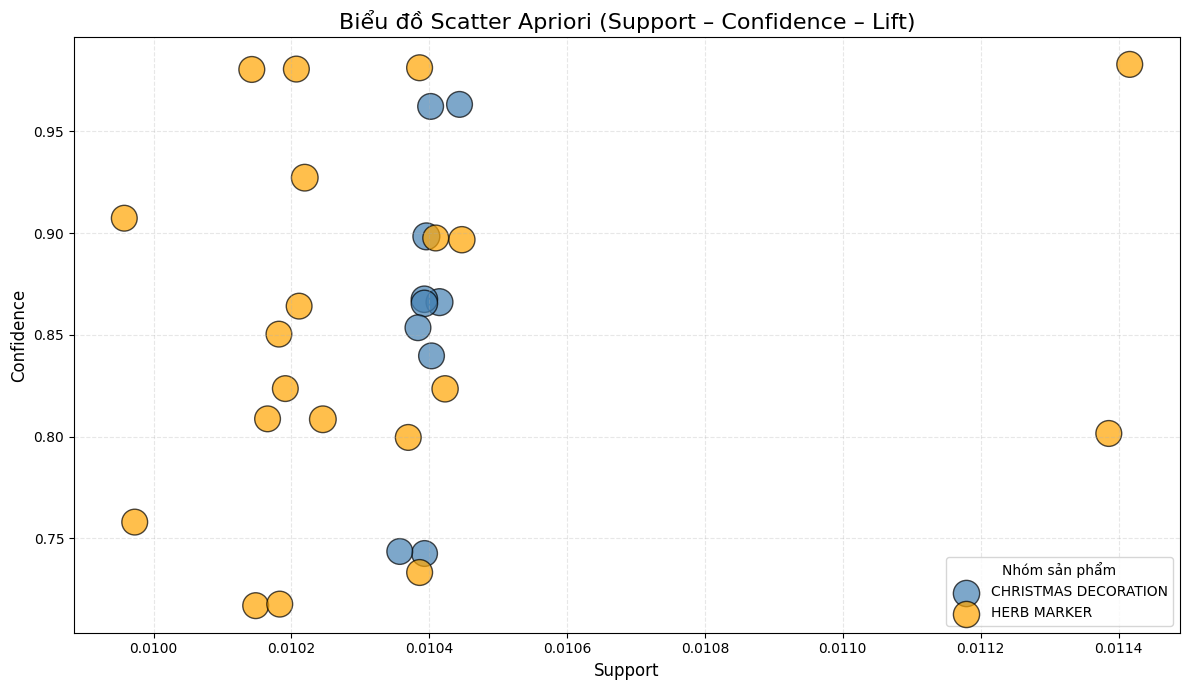

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Lấy 30 luật mạnh nhất
plot_rules = rules_df.head(30).copy()

# Thêm cột "Group" để tô màu theo nhóm sản phẩm
def get_group(row):
    text = (row["Antecedent"] + " " + row["Consequent"]).upper()
    if "HERB MARKER" in text:
        return "HERB MARKER"
    elif "CHRISTMAS TREE" in text:
        return "CHRISTMAS DECORATION"
    else:
        return "OTHER"

plot_rules["Group"] = plot_rules.apply(get_group, axis=1)

# Jitter nhẹ để điểm không đè lên nhau
np.random.seed(42)
plot_rules["Support_j"] = plot_rules["Support"] + np.random.randn(len(plot_rules))*0.00003
plot_rules["Confidence_j"] = plot_rules["Confidence"] + np.random.randn(len(plot_rules))*0.001

plt.figure(figsize=(12, 7))

colors = {"HERB MARKER": "orange",
          "CHRISTMAS DECORATION": "steelblue",
          "OTHER": "grey"}

for grp, sub in plot_rules.groupby("Group"):
    plt.scatter(
        sub["Support_j"],
        sub["Confidence_j"],
        s=sub["Lift"]*5,
        color=colors[grp],
        alpha=0.7,
        edgecolor="black",
        label=grp
    )

plt.title("Biểu đồ Scatter Apriori (Support – Confidence – Lift)", fontsize=16)
plt.xlabel("Support", fontsize=12)
plt.ylabel("Confidence", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(title="Nhóm sản phẩm")
plt.tight_layout()
plt.show()

**Nhận xét biểu đồ:**

Biểu đồ Scatter thể hiện các luật Apriori theo Support (trục X), Confidence (trục Y) và Lift (kích thước điểm). Màu sắc cho thấy hai nhóm sản phẩm chính: HERB MARKER (cam) và CHRISTMAS DECORATION (xanh) có Confidence cao và Lift lớn, phản ánh xu hướng khách hàng mua các sản phẩm này theo bộ. Support thấp nhưng Lift và Confidence mạnh cho thấy các luật Apriori mang giá trị lớn trong phân tích hành vi mua hàng và đề xuất sản phẩm.

### Biểu đồ Bar thể hiện Lift của 10 luật mạnh nhất

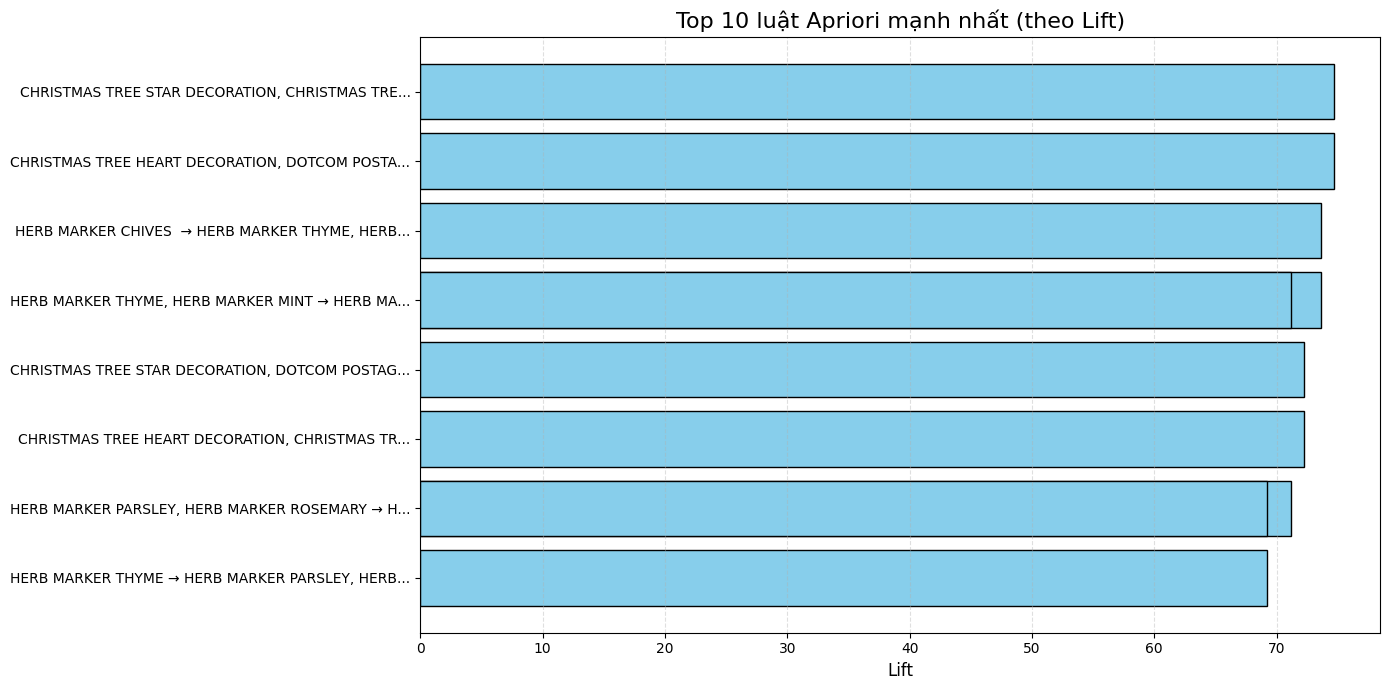

In [16]:
import matplotlib.pyplot as plt

# Lấy 10 luật Lift cao nhất
top10 = rules_df.head(10).copy()

# Hàm rút gọn tên luật
def shorten_rule(a, c, max_len=45):
    text = f"{a} → {c}"
    return text if len(text) <= max_len else text[:max_len] + "..."

top10["Rule"] = [
    shorten_rule(a, c)
    for a, c in zip(top10["Antecedent"], top10["Consequent"])
]

plt.figure(figsize=(14, 7))

plt.barh(top10["Rule"], top10["Lift"], color="skyblue", edgecolor="black")

plt.xlabel("Lift", fontsize=12)
plt.title("Top 10 luật Apriori mạnh nhất (theo Lift)", fontsize=16)

plt.gca().invert_yaxis()  # luật mạnh nhất nằm trên cùng
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

**Nhận xét biểu đồ:**

Biểu đồ Bar cho thấy top 10 luật Apriori có Lift cao đều thuộc hai nhóm sản phẩm: CHRISTMAS TREE DECORATION và HERB MARKER. Các sản phẩm này có xu hướng được mua theo bộ với mức Lift rất cao, chứng tỏ sự liên kết mạnh mẽ và khả năng mua kèm rõ rệt. Đây là những nhóm sản phẩm lý tưởng để trưng bày theo set, tạo combo hoặc sử dụng trong các chương trình gợi ý sản phẩm

### Network Graph: Hiển thị mối quan hệ giữa các sản phẩm

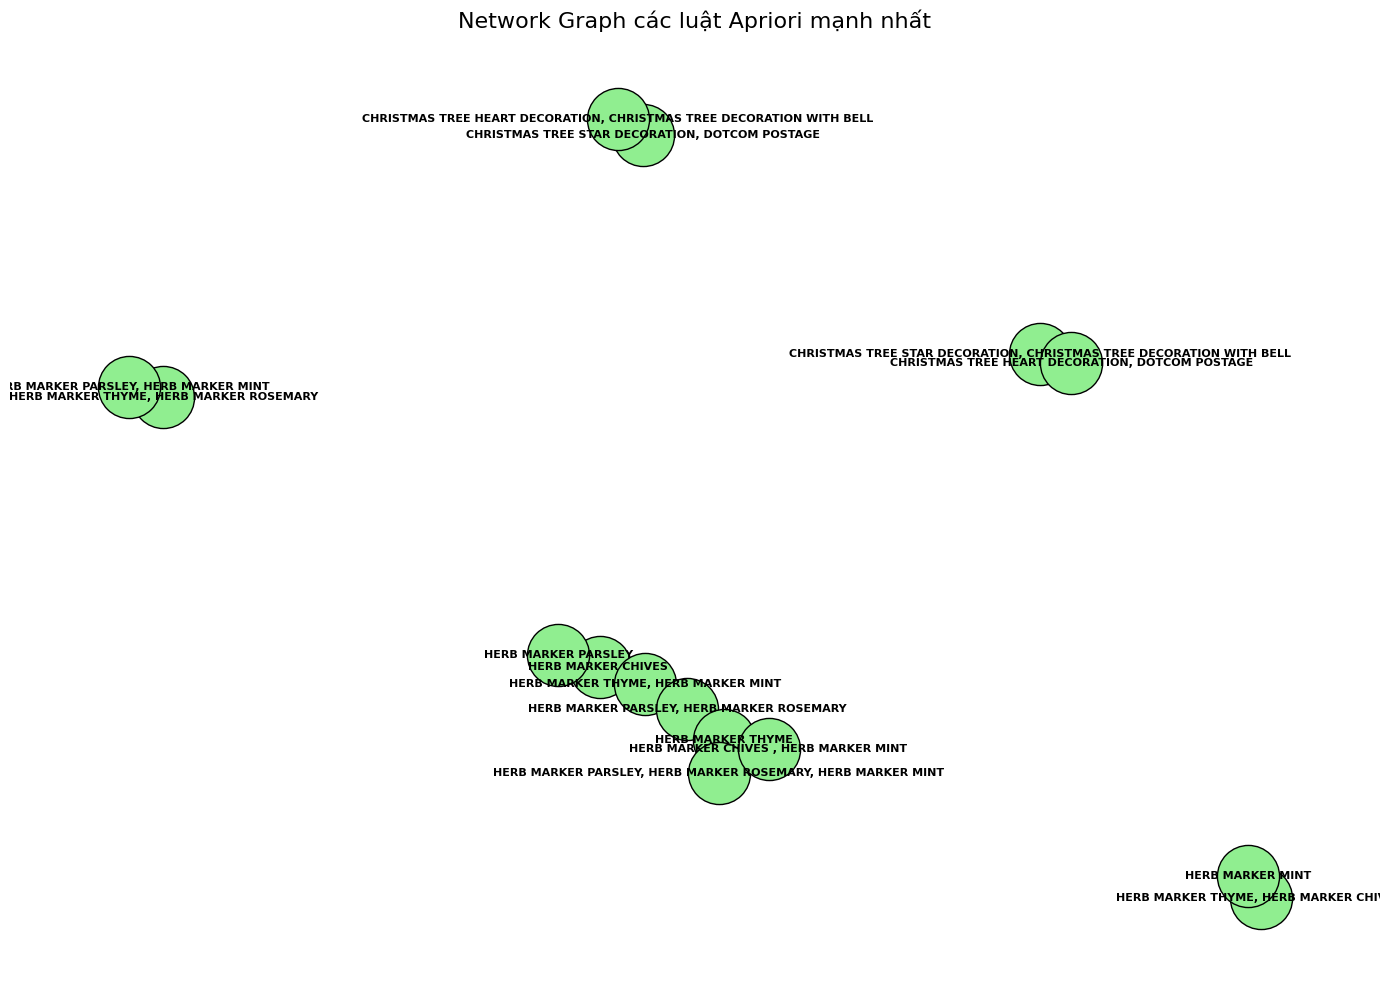

In [17]:
# Chọn 20 luật mạnh nhất
topN = rules_df.head(20).copy()

# Tạo đồ thị có hướng
G = nx.DiGraph()

# Thêm cạnh (edge) từ Antecedent -> Consequent, trọng số = Lift
for _, row in topN.iterrows():
    a = row["Antecedent"]
    c = row["Consequent"]
    lift = row["Lift"]
    G.add_edge(a, c, weight=lift)

plt.figure(figsize=(14, 10))

# Layout (bố trí vị trí các nút)
pos = nx.spring_layout(G, k=0.5, seed=42)

# Lấy trọng số để điều chỉnh độ dày cạnh
weights = [G[u][v]['weight'] for u, v in G.edges()]

# Vẽ node
nx.draw_networkx_nodes(
    G, pos,
    node_size=2000,
    node_color="lightgreen",
    edgecolors="black"
)

# Vẽ edge: độ dày tỷ lệ với lift
nx.draw_networkx_edges(
    G, pos,
    arrowstyle="->",
    arrowsize=15,
    width=[w / 20 for w in weights],  # chia cho 20 cho đỡ to
    alpha=0.7
)

# Vẽ nhãn node
nx.draw_networkx_labels(
    G, pos,
    font_size=8,
    font_weight="bold"
)

plt.title("Network Graph các luật Apriori mạnh nhất", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()

**Nhận xét biểu đồ:**

Network graph thể hiện mối quan hệ giữa các sản phẩm trong 20 luật Apriori mạnh nhất. Mỗi nút biểu diễn một tập sản phẩm (Antecedent hoặc Consequent), mũi tên thể hiện chiều của luật, còn độ dày cạnh tỷ lệ với giá trị Lift. Có thể thấy các cụm sản phẩm HERB MARKER và CHRISTMAS TREE DECORATION tạo thành những “cụm nút” liên kết chặt chẽ, cho thấy chúng thường được mua kèm với nhau trong cùng một đơn hàng. Điều này củng cố kết luận rằng khách hàng có xu hướng mua trọn bộ sản phẩm thuộc cùng chủ đề.

## 8. Kết luận tổng quát

Giải thuật Apriori là công cụ mạnh mẽ giúp khám phá các mối quan hệ ẩn giữa các sản phẩm dựa trên dữ liệu giao dịch. Các luật thu được trong nghiên cứu này mang giá trị thực tiễn cao, hỗ trợ trực tiếp cho hoạt động kinh doanh và chiến lược bán hàng. Dữ liệu Online Retail phản ánh rõ ràng xu hướng mua theo bộ của khách hàng, và Apriori đã giúp làm sáng tỏ các mô hình mua sắm này một cách trực quan và dễ hiểu.

# Kết thúc